In [1]:
#%%time
import os
import re
import sys
import gzip
import math
import random
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

from ast import literal_eval
import warnings
# 忽略 FutureWarning 类型警告
warnings.simplefilter(action='ignore', category=FutureWarning)
# 忽略特定类型的警告：忽略 scanpy包中含有 ignore 的 UserWarning 类型警告
warnings.filterwarnings("ignore", category=UserWarning, module="scanpy")
# 禁用 pandas 包中的 SettingWithCopyWarning 类型警告  
pd.options.mode.chained_assignment = None  # 或 'raise' 表示引发异常

import inferECC
from inferECC import *

random.seed(21)
np.random.seed(21)

species value: hg38
species == 'mm10':  False


In [2]:
def get_all_folders(path):
    folders = [f for f in os.listdir(path) if os.path.isdir(os.path.join(path, f))]
    return folders
"""
# 指定路径
target_path = library_dir # '/your/target/directory'
# 获取所有文件夹
folders_list = get_all_folders(target_path)
"""

"\n# 指定路径\ntarget_path = library_dir # '/your/target/directory'\n# 获取所有文件夹\nfolders_list = get_all_folders(target_path)\n"

In [3]:
from matplotlib_venn import venn2
import upsetplot

In [4]:
upsetplot_path = "D:/02.project/18.ecDNA/02.code/v0.1.1/fig_cpr_rbg_stat_2/07.tracing/03.upsetplot_all"
if(os.path.exists(upsetplot_path) != True): os.makedirs(upsetplot_path)
os.chdir(upsetplot_path)
print(os.getcwd())

D:\02.project\18.ecDNA\02.code\v0.1.1\fig_cpr_rbg_stat_2\07.tracing\03.upsetplot_all


In [5]:
adata_list = list()
for i in range(7):
    primary_path = f"D:/02.project/18.ecDNA/02.code/v0.1.1/fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/s{i}"
    adata_temp = sc.read(primary_path+"/cellXecDNA_fi.mtx_fbg_m3std_pair_clone.h5ad")
    adata_list.append(adata_temp)

C:\Users\wangyuhang\.conda\envs\py310\lib\site-packages\anndata\_core\anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
C:\Users\wangyuhang\.conda\envs\py310\lib\site-packages\anndata\_core\anndata.py:1897: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
C:\Users\wangyuhang\.conda\envs\py310\lib\site-packages\anndata\_core\anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
C:\Users\wangyuhang\.conda\envs\py310\lib\site-packages\anndata\_core\anndata.py:1897: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
C:\Users\wangyuhang\.conda\envs\py310\lib\site-packages\anndata\_core\anndata.py:183: ImplicitModificationWarning: Trans

In [6]:
Metastatic_var_df = pd.concat([adata.var["Metastatic"] for adata in adata_list], axis=1)
Metastatic_var_df.columns = [adata.obs["cancer"][0]+"_"+adata.obs["sample"][0].split("-")[0] for adata in adata_list]
Metastatic_var_df = Metastatic_var_df.fillna(False)
# 1. 将每一行的所有元素求和
Metastatic_var_df['row_sum'] = Metastatic_var_df.sum(axis=1)
# 2. 删除和为0的行
Metastatic_var_df = Metastatic_var_df[Metastatic_var_df['row_sum'] != 0]
# 3.删除辅助列 'row_sum'
Metastatic_var_df = Metastatic_var_df.drop(columns=['row_sum'])
Metastatic_var_df

,PDAC_ht270p1,CRC_cm1563c1,CRC_cm663c1,UCEC_cpt4427du,UCEC_cpt1541du,UCEC_cpt2373du,UCEC_cpt704du
chr_100k,,,,,,,
chr10:101000000_101100000,True,False,True,False,True,True,False
chr10:102400000_102500000,True,True,True,True,True,True,False
chr10:132400000_132500000,True,False,True,False,True,False,False
chr10:132500000_132600000,True,True,True,False,True,False,False
chr10:133200000_133300000,True,False,True,True,False,False,False
...,...,...,...,...,...,...,...
chr5:147400000_147500000,False,False,False,False,False,False,True
chr5:172900000_173000000,False,False,False,False,False,False,True
chr6:169200000_169300000,False,False,False,False,False,False,True


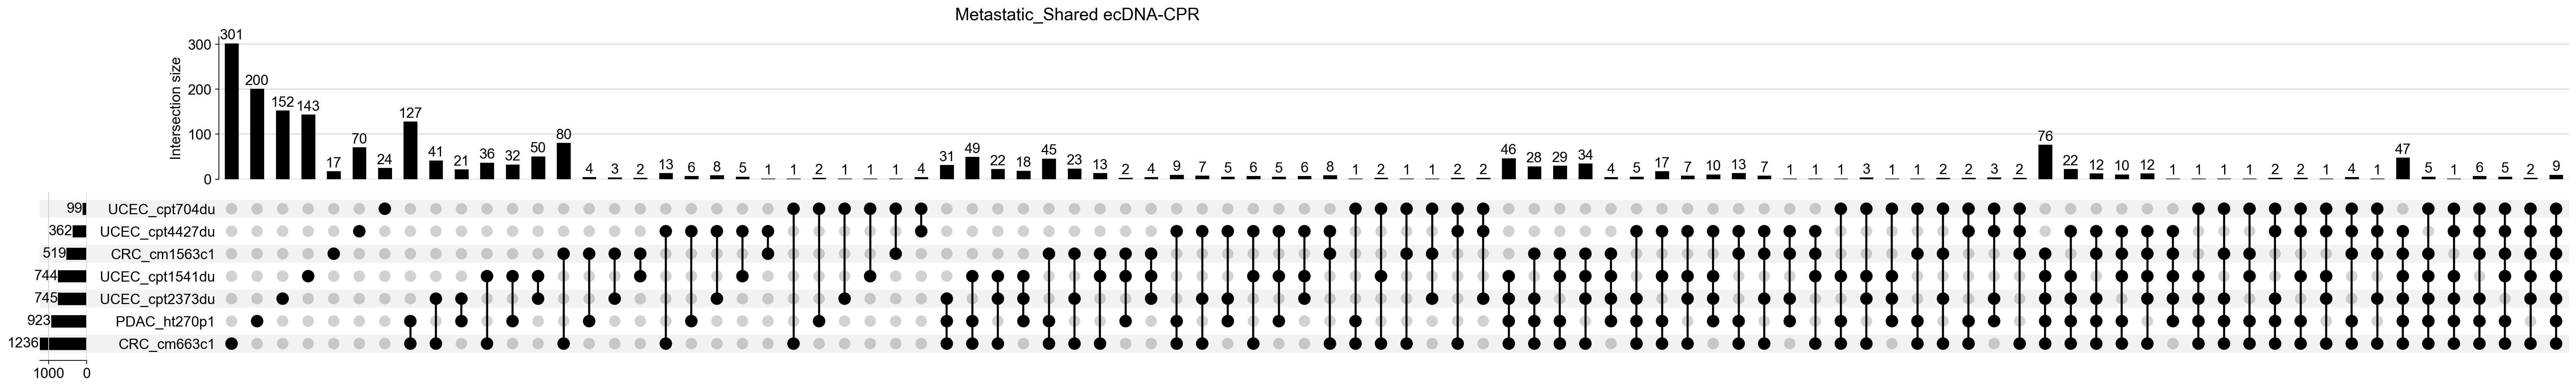

In [7]:
### input
cancer_data = Metastatic_var_df.copy()

# 检查行名是否有重复
duplicates = cancer_data.index.duplicated(keep='first')
# 如果有重复的行名，删除重复的行
if duplicates.any():
    cancer_data = cancer_data.loc[~duplicates]
#"""
column_names = cancer_data.columns.tolist()
unique_combinations = cancer_data.groupby(column_names).size()

### pan-cancer Number ecdna
cancer_data["row_sum"] = cancer_data.sum(axis=1)
col_name = cancer_data.sum(axis=0)
col_name.name = 'col_name'
cancer_data = cancer_data.append(col_name, ignore_index=False)
cancer_data.to_csv(f'./f01-upsetplot_pan-cancer_all_ecdna.tsv',sep="\t",index=True)

### plot all
upsetplot.plot(unique_combinations, show_counts=True)
plt.suptitle(f'Metastatic_Shared ecDNA-CPR')
#plt.show()
try:
    print("")
    plt.savefig(f'./f02-Metastatic_Shared_all.pdf', bbox_inches='tight')
except Exception as e:
    print(f"An error occurred: {e}")

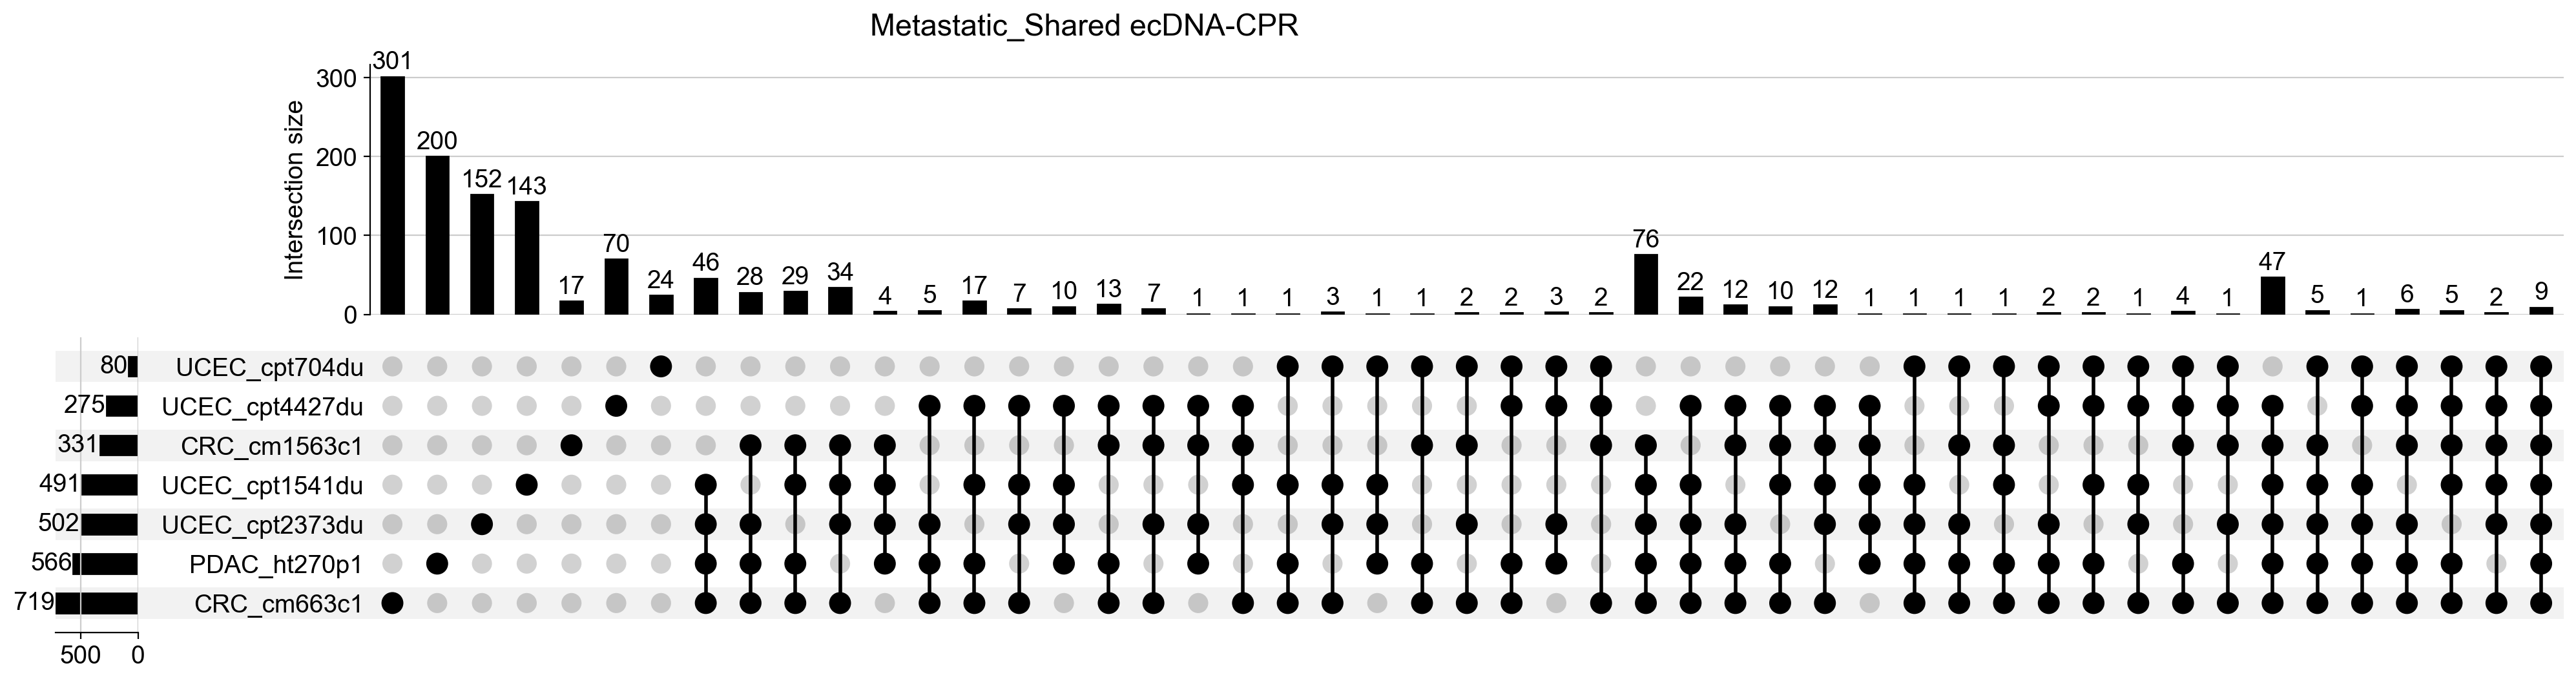

In [8]:
## 提取sample specific的元素和 sample common 的元素（>=0.7sample）
a=pd.DataFrame(unique_combinations.index.values.tolist(), columns=unique_combinations.index.names)
a["sum"] = a.sum(axis=1)
#rows_sum_selected = a.loc[(a['sum'] == 1)|(a['sum'] >= 0.7*data.shape[1])].index
rows_sum_selected = a.loc[(a['sum'] == 1)|(a['sum'] >= 4)].index
selected_counts = unique_combinations.iloc[rows_sum_selected]
# 检查行名是否有重复
duplicates = selected_counts.index.duplicated(keep='first')
# 如果有重复的行名，删除重复的行
if duplicates.any():
    selected_counts = selected_counts.loc[~duplicates]

### plot part
upsetplot.plot(selected_counts, show_counts=True)
plt.suptitle(f'Metastatic_Shared ecDNA-CPR')
#plt.show()
try:
    print("")
    plt.savefig(f'./f03-Metastatic_Shared_selected.pdf', bbox_inches='tight')
except Exception as e:
    print(f"An error occurred: {e}")


In [9]:
# 生成颜色列表
from matplotlib.colors import to_hex
hex_colors = [to_hex(color) for color in sns.color_palette()]
cancer_pal = sns.color_palette(hex_colors)
#cancer_pal[6],cancer_pal[16]

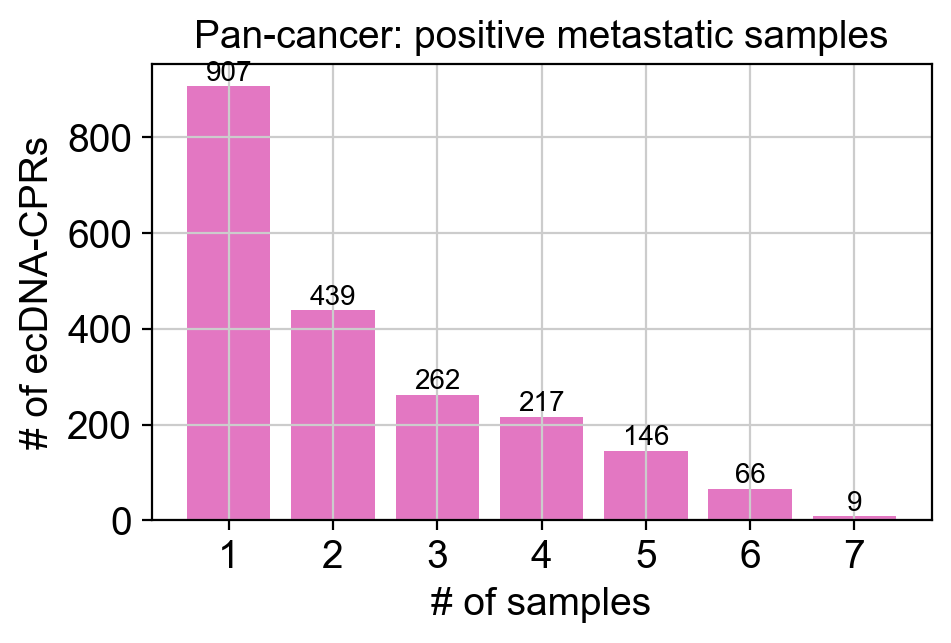

In [10]:
## 提取sample specific的元素和 sample common 的元素（>=0.7sample）
a=pd.DataFrame(unique_combinations.index.values.tolist(), columns=unique_combinations.index.names)
a["sum"] = a.sum(axis=1)

a["N_cancers"] = a["sum"]
a["N_ecdnaCPRs"] = unique_combinations.values
a = a.drop('sum', axis=1)
a.to_csv(f'./f04-upsetplot_pan-cancer_all_ecdna_stat.tsv',sep="\t",index=True)

c = a.groupby("N_cancers")["N_ecdnaCPRs"].sum().reset_index()
c.to_csv(f'./f05-upsetplot_pan-cancer_all_ecdna_stat_sum.tsv',sep="\t",index=True)

plt.figure(figsize=(5,3))  # 创建一个新的图形，设置大小
bars = plt.bar(x='N_cancers', height='N_ecdnaCPRs',data=c, color=cancer_pal[6])  # 绘制条形图
plt.xlabel('# of samples')  # 设置x轴标签
plt.ylabel('# of ecDNA-CPRs')  # 设置y轴标签
plt.xticks(np.arange(min(c['N_cancers']), max(c['N_cancers'])+1, 1))
plt.title('Pan-cancer: positive metastatic samples')  # 设置标题
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, round(yval, 2), ha='center', va='bottom',fontsize=10)
#plt.show()  # 显示图形
plt.savefig(f'./f06-barplot_pan-cancer_all_ecdna_stat_sum.pdf', bbox_inches='tight')


In [11]:
a = Metastatic_var_df.copy()
# 检查行名是否有重复
duplicates = a.index.duplicated(keep='first')
# 如果有重复的行名，删除重复的行
if duplicates.any():
    a = a.loc[~duplicates]
a["sum"] = a.sum(axis=1)
a

,PDAC_ht270p1,CRC_cm1563c1,CRC_cm663c1,UCEC_cpt4427du,UCEC_cpt1541du,UCEC_cpt2373du,UCEC_cpt704du,sum
chr_100k,,,,,,,,
chr10:101000000_101100000,True,False,True,False,True,True,False,4
chr10:102400000_102500000,True,True,True,True,True,True,False,6
chr10:132400000_132500000,True,False,True,False,True,False,False,3
chr10:132500000_132600000,True,True,True,False,True,False,False,4
chr10:133200000_133300000,True,False,True,True,False,False,False,3
...,...,...,...,...,...,...,...,...
chr5:147400000_147500000,False,False,False,False,False,False,True,1
chr5:172900000_173000000,False,False,False,False,False,False,True,1
chr6:169200000_169300000,False,False,False,False,False,False,True,1


In [55]:
Meta_shared = a[a["sum"]>=4].index.to_list()
len(Meta_shared)

438

In [13]:
pseudo_list = list()
for i in range(7):
    primary_path = f"D:/02.project/18.ecDNA/02.code/v0.1.1/fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/s{i}"
    tb_temp = pd.read_table(primary_path+f"/f17-sort_exp_sig.xls",index_col=0)
    # 提取所有的列名，得到一个列名组成的list
    columns_list = tb_temp.columns.tolist()
    # 截取这个list的后一半的元素，得到一个新的list
    half_index = len(columns_list) // 3
    new_list = columns_list[half_index:]
    pseudo_list.append(new_list)

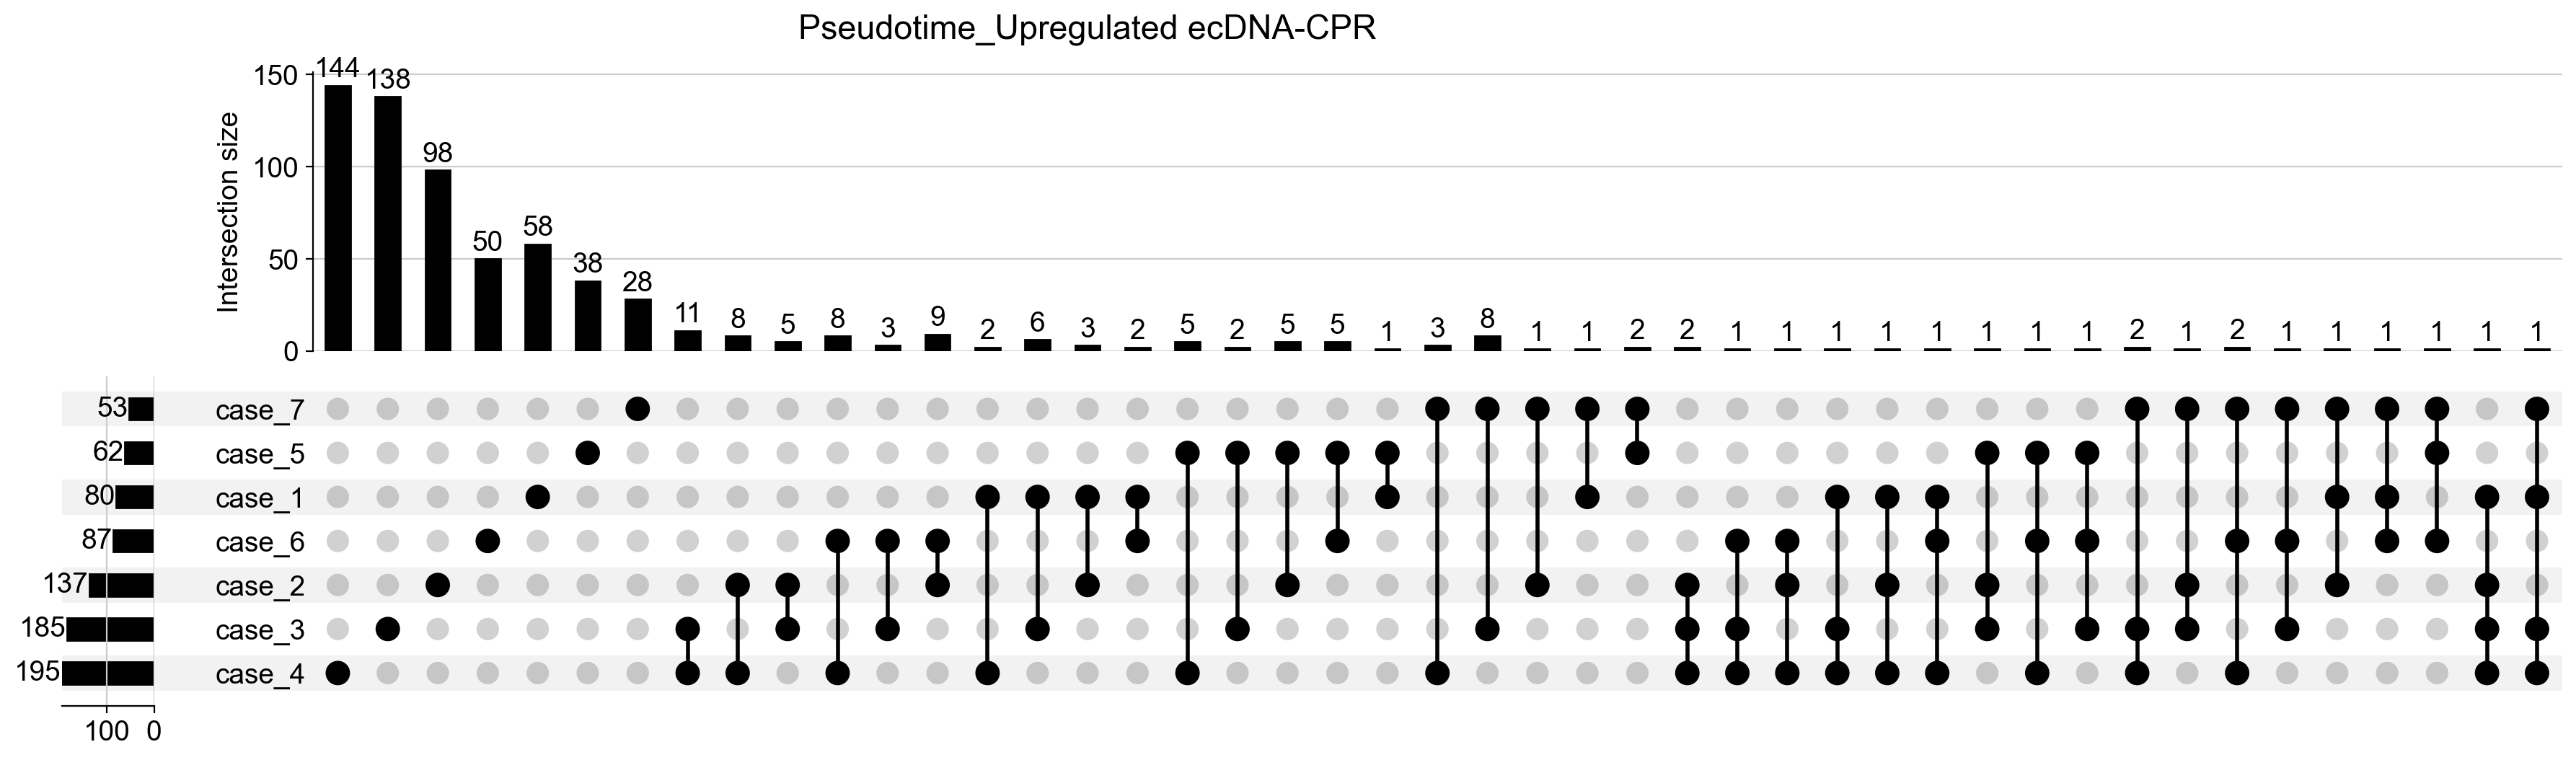

In [14]:
import upsetplot
# 将列表转换为适合UpSetPlot的数据格式
contents = {f'case_{i+1}': set(lst) for i, lst in enumerate(pseudo_list)}
upset_data = upsetplot.from_contents(contents)
# 绘制UpSet图
upset = upsetplot.UpSet(upset_data, show_counts=True)
upset.plot()
plt.suptitle(f'Pseudotime_Upregulated ecDNA-CPR')
plt.savefig(f'./f07-Pseudotime_Upregulated.pdf', bbox_inches='tight')
# 显示图形
plt.show()

In [15]:
from collections import Counter
# 统计每个元素在多少个列表中出现
element_counter = Counter()
for lst in pseudo_list:
    element_counter.update(set(lst))
# 提取在两个或更多列表中出现的元素
pseudo_elements = {elem for elem, count in element_counter.items() if count >= 2}
len(pseudo_elements)

111

In [16]:
increased_list = list()
for i in range(7):
    primary_path = f"D:/02.project/18.ecDNA/02.code/v0.1.1/fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/s{i}"
    tb_temp = pd.read_table(primary_path+f"/f27-ecDNA_change-seu.markers.xls",index_col=0)
    list_temp = tb_temp[(tb_temp["cluster"]=="Clone_Increased") & (tb_temp["avg_log2FC"]>2) & (tb_temp["p_val"]<9.05)]["gene"].to_list()
    increased_list.append(list_temp)

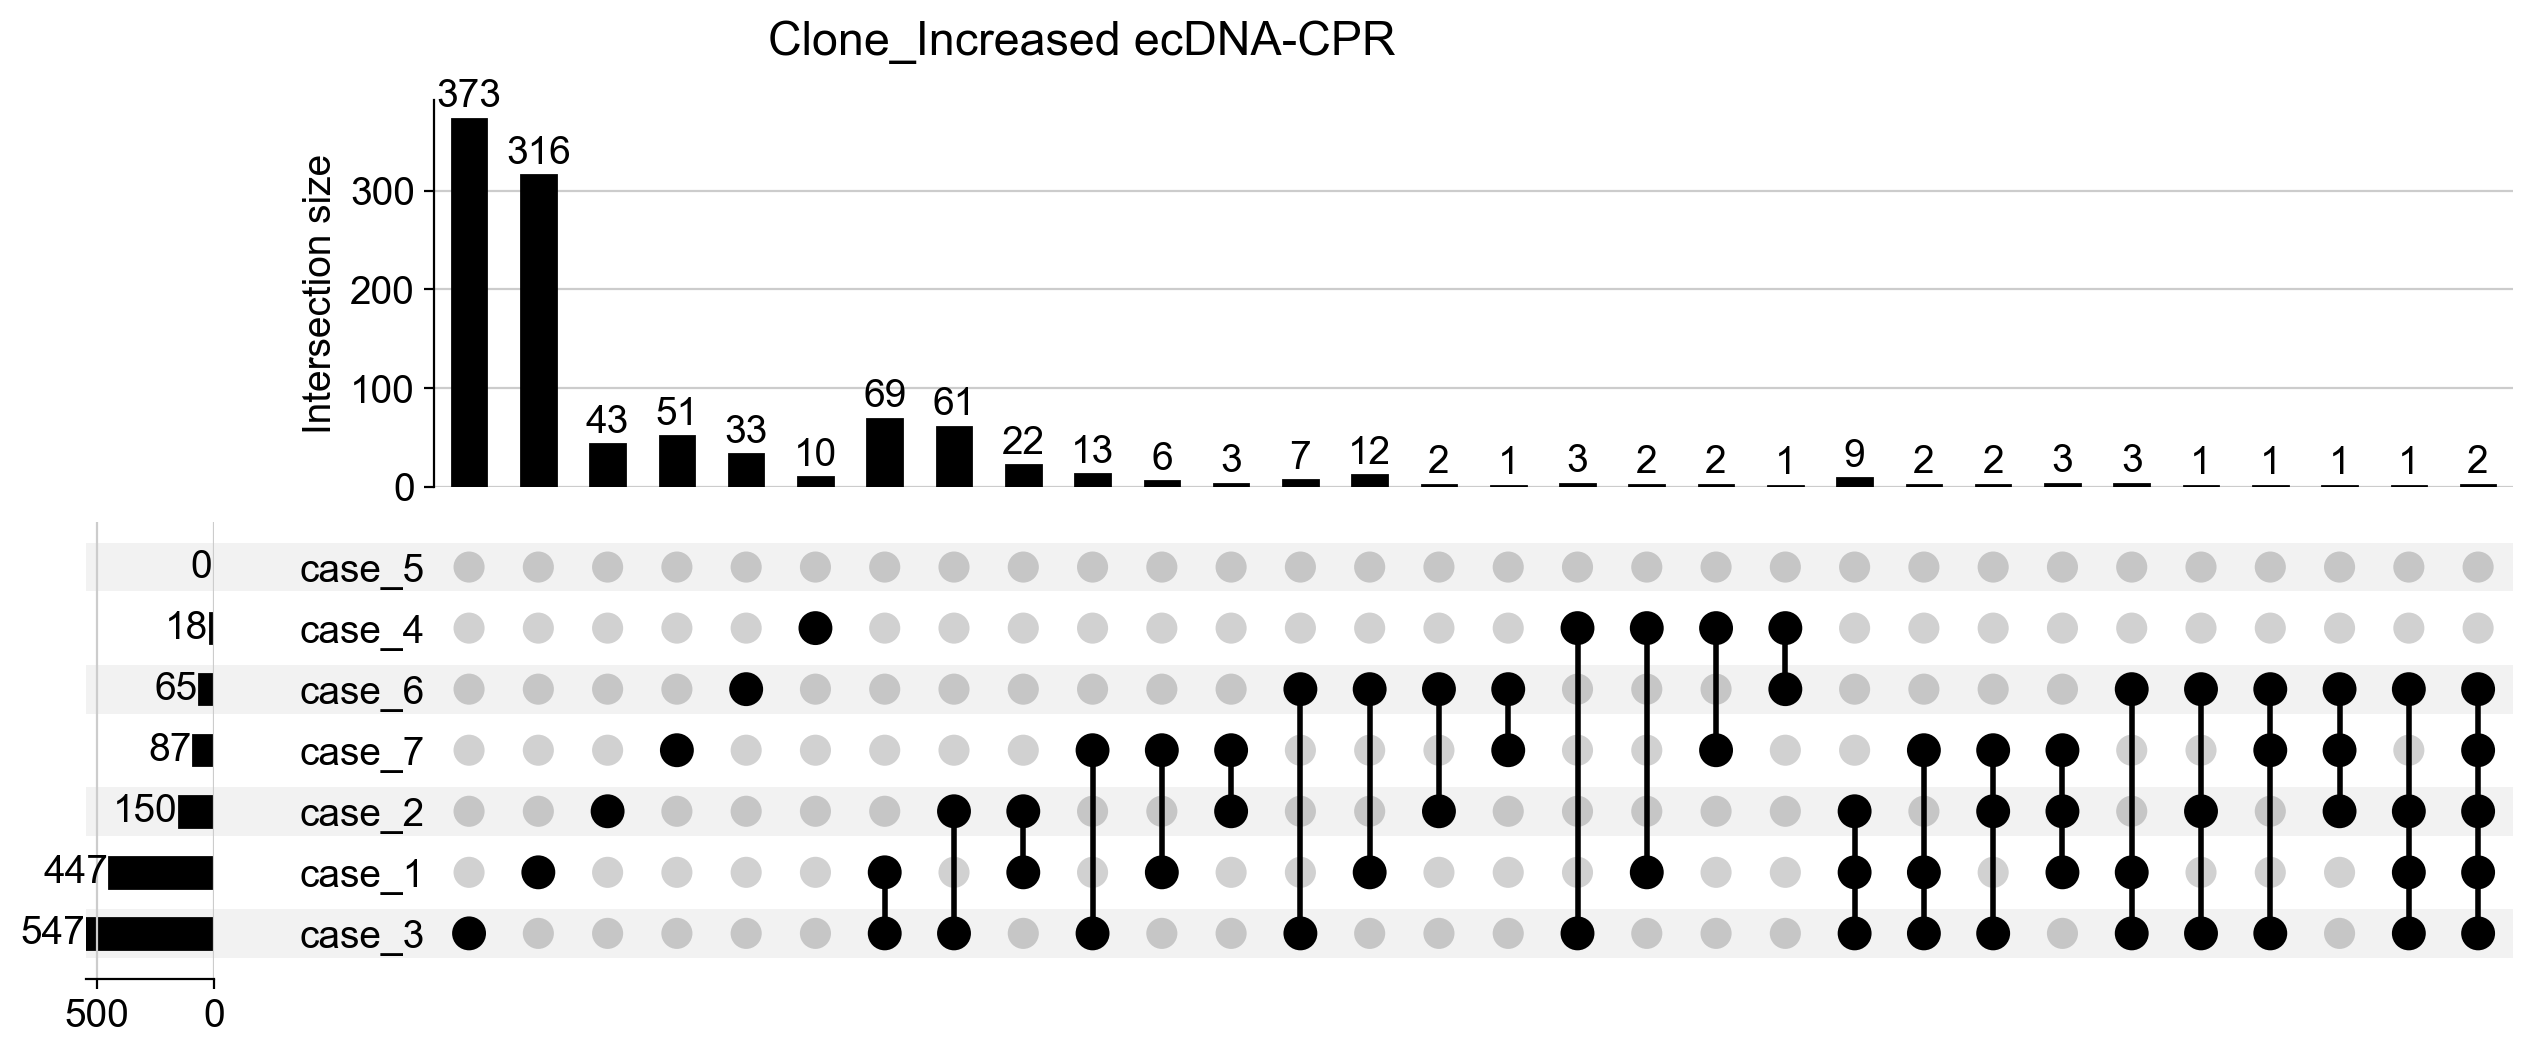

In [17]:
import upsetplot
# 将列表转换为适合UpSetPlot的数据格式
contents = {f'case_{i+1}': set(lst) for i, lst in enumerate(increased_list)}
upset_data = upsetplot.from_contents(contents)
# 绘制UpSet图
upset = upsetplot.UpSet(upset_data, show_counts=True)
upset.plot()
plt.suptitle(f'Clone_Increased ecDNA-CPR')
plt.savefig(f'./f08-Clone_Increased.pdf', bbox_inches='tight')
# 显示图形
plt.show()

In [18]:
from collections import Counter
# 统计每个元素在多少个列表中出现
element_counter = Counter()
for lst in increased_list:
    element_counter.update(set(lst))
# 提取在两个或更多列表中出现的元素
increased_elements = {elem for elem, count in element_counter.items() if count >= 2}
len(increased_elements)

229

In [56]:
############# MAC

In [57]:
MAC_all = [list(increased_elements),list(pseudo_elements),Meta_shared]

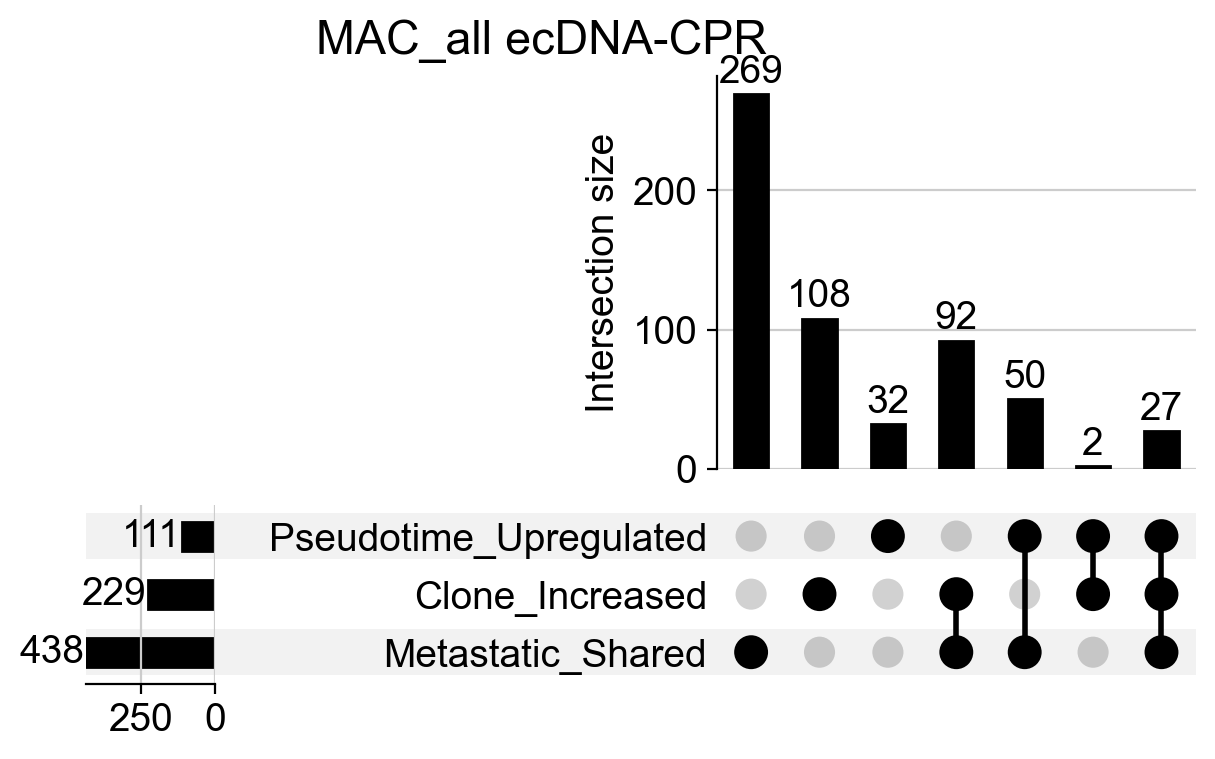

In [58]:
import upsetplot
# 将列表转换为适合UpSetPlot的数据格式
keys = ['Clone_Increased', 'Pseudotime_Upregulated', 'Metastatic_Shared']
contents = {keys[i]: set(lst) for i, lst in enumerate(MAC_all)}
upset_data = upsetplot.from_contents(contents)
# 绘制UpSet图
upset = upsetplot.UpSet(upset_data, show_counts=True)
upset.plot()
plt.suptitle(f'MAC_all ecDNA-CPR')
plt.savefig(f'./f09-MAC_all.pdf', bbox_inches='tight')
# 显示图形
plt.show()

In [59]:
from collections import Counter
# 统计每个元素在多少个列表中出现
element_counter = Counter()
for lst in MAC_all:
    element_counter.update(set(lst))
# 提取在两个或更多列表中出现的元素
MAC_elements = {elem for elem, count in element_counter.items() if count == 3}
print(len(MAC_elements))
MAC_elements

27


{'chr11:500000_600000',
 'chr12:6700000_6800000',
 'chr17:1500000_1600000',
 'chr17:48000000_48100000',
 'chr17:74700000_74800000',
 'chr17:78300000_78400000',
 'chr17:82000000_82100000',
 'chr19:10800000_10900000',
 'chr19:11100000_11200000',
 'chr19:13800000_13900000',
 'chr19:17200000_17300000',
 'chr19:2000000_2100000',
 'chr19:3300000_3400000',
 'chr1:204100000_204200000',
 'chr1:248800000_248900000',
 'chr1:6400000_6500000',
 'chr20:62300000_62400000',
 'chr20:62700000_62800000',
 'chr20:63500000_63600000',
 'chr20:63900000_64000000',
 'chr20:64000000_64100000',
 'chr22:50200000_50300000',
 'chr2:219500000_219600000',
 'chr3:49400000_49500000',
 'chr6:33200000_33300000',
 'chr7:101100000_101200000',
 'chr9:33100000_33200000'}

In [60]:
MAC_all = [set(MAC_all[0]),set(MAC_all[1]),set(MAC_all[2])]

In [61]:
import matplotlib_venn
print(matplotlib_venn.__file__)

C:\Users\wangyuhang\.conda\envs\py310\lib\site-packages\matplotlib_venn\__init__.py


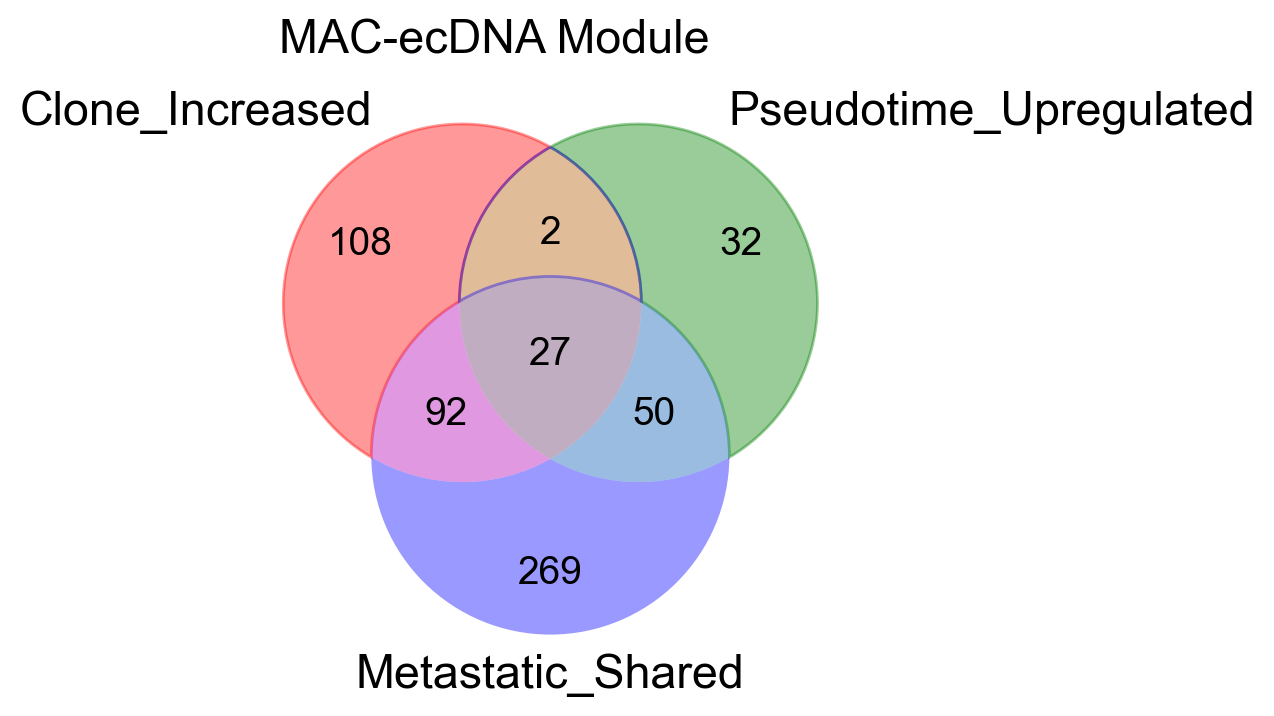

In [62]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

# 绘制三集合韦恩图
pv = venn3([set(MAC_all[0]), set(MAC_all[1]), set(MAC_all[2])], ('Clone_Increased', 'Pseudotime_Upregulated', 'Metastatic_Shared'))

# 设置颜色
venn3_circles = pv
for patch, color in zip(venn3_circles.patches, ['red', 'green', 'blue']):
    if patch:
        patch.set_edgecolor(color)
plt.suptitle(f'MAC-ecDNA Module')
plt.savefig(f'./f10-MAC_all_venn3.pdf', bbox_inches='tight')
# 显示图形
plt.show()

In [63]:
####### circle viz

In [64]:
df = pd.DataFrame(list(MAC_elements), columns=['names'])
df["chr_raw"] = df["names"]
df_ecdna_gene = genebody_region(df_fragments=df,species="hg38")
df_ecdna_gene['oncogene'] = df_ecdna_gene['genebody_region_gene'].apply(custom_transform)
df_ecdna_gene

species value: hg38


,names,chr_raw,genebody_region,genebody_region_gene,oncogene
0,chr2:219500000_219600000,chr2:219500000_219600000,12,"[AC053503.11, GMPPA, ASIC4, CHPF, TMEM198, RP1...",[]
1,chr17:74700000_74800000,chr17:74700000_74800000,6,"[RAB37, CD300LF, RP11-452I5.2, SLC9A3R1, NAT9,...",[]
2,chr19:2000000_2100000,chr19:2000000_2100000,7,"[BTBD2, LLNLR-304A6.1, LLNLR-304A6.2, AC007136...",[]
3,chr19:3300000_3400000,chr19:3300000_3400000,4,"[AC010649.1, AC007792.1, NFIC, AC005514.2]",[]
4,chr19:13800000_13900000,chr19:13800000_13900000,9,"[ZSWIM4, RN7SL619P, MIR24-2, MIR27A, MIR23A, N...",[]
5,chr12:6700000_6800000,chr12:6700000_6800000,10,"[PIANP, RNU6-781P, RP4-761J14.9, COPS7A, RP4-7...",[]
6,chr1:6400000_6500000,chr1:6400000_6500000,6,"[HES2, ESPN, MIR4252, RP1-202O8.2, TNFRSF25, P...",[]
7,chr17:78300000_78400000,chr17:78300000_78400000,5,"[AC061992.2, SOCS3, RP11-806H10.4, RN7SL236P, ...",[]
8,chr1:204100000_204200000,chr1:204100000_204200000,8,"[SOX13, RP11-74C13.4, ETNK2, RP11-74C13.3, REN...",[]
9,chr19:11100000_11200000,chr19:11100000_11200000,4,"[LDLR, SPC24, KANK2, DOCK6]",[]


In [65]:
df_ecdna_gene.to_csv('f11-MAC-df_ecdna_gene.xls', sep='\t', index=True)

In [66]:
outfile_path = "D:/02.project/18.ecDNA/02.code/v0.1.1/fig_cpr_rbg_stat_2/07.tracing/03.upsetplot_all/f12-circle_viz"
if(os.path.exists(outfile_path) != True): os.makedirs(outfile_path)
os.chdir(outfile_path)
print(os.getcwd())

D:\02.project\18.ecDNA\02.code\v0.1.1\fig_cpr_rbg_stat_2\07.tracing\03.upsetplot_all\f12-circle_viz


In [67]:
circle_graph_file(df=df_ecdna_gene,outfile_path=outfile_path)

D:\02.project\18.ecDNA\02.code\v0.1.1\fig_cpr_rbg_stat_2\07.tracing\03.upsetplot_all\f12-circle_viz
Done: amplicon_cycles.txt
Done: amplicon_graph.txt


In [31]:
### anno ecdna2gene oncogene pathway
### import ecdna2gene2pathway function

In [40]:
#### generate circle viz pre-files
### import generate_circle_viz_pre_files function